## **IMDB Movies Analysis Using PCA and Clustering**
- This notebook presents a comprehensive analysis of the top 50 IMDb-rated movies using dimensionality reduction and clustering techniques
- Dataset Overview- The dataset used is titled IMDB-Movies.csv, containing details of the **Top 50 IMDb-rated movies**. It includes both numerical and categorical variables that describe each movie’s attributes.

In [6]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')
from sklearn.impute import SimpleImputer

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

### Data Loading and Exploration

In [ ]:
# Load the dataset
df = pd.read_csv("IMDB-Movies.csv")

# Print basic information
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
df.head()


Dataset shape: (50, 11)

First few rows:


,Unnamed: 0,Title,Genre,Description,Director,Actors,Year,Runtime..Minutes.,Rating,Votes,Revenue..Millions.
0,1,The Dark Knight,"Action,Crime,Drama",When the menace known as the Joker wreaks havo...,Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart,Mi...",2008,152,9.0,1791916,533.32
1,2,Inception,"Action,Adventure,Sci-Fi","A thief, who steals corporate secrets through ...",Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellen...",2010,148,8.8,1583625,292.57
2,3,Dangal,"Action,Biography,Drama",Former wrestler Mahavir Singh Phogat and his t...,Nitesh Tiwari,"Aamir Khan, Sakshi Tanwar, Fatima Sana Shaikh,...",2016,161,8.8,48969,11.15
3,4,Interstellar,"Adventure,Drama,Sci-Fi",A team of explorers travel through a wormhole ...,Christopher Nolan,"Matthew McConaughey, Anne Hathaway, Jessica Ch...",2014,169,8.6,1047747,187.99
4,5,Kimi no na wa,"Animation,Drama,Fantasy",Two strangers find themselves linked in a biza...,Makoto Shinkai,"Ryûnosuke Kamiki, Mone Kamishiraishi, Ryô Nari...",2016,106,8.6,34110,4.68


In [8]:
print("\nData types:")
print(df.dtypes)

print("\nSummary statistics for numerical variables:")
print(df.describe())



Data types:
Unnamed: 0              int64
Title                  object
Genre                  object
Description            object
Director               object
Actors                 object
Year                    int64
Runtime..Minutes.       int64
Rating                float64
Votes                   int64
Revenue..Millions.    float64
dtype: object

Summary statistics for numerical variables:
       Unnamed: 0         Year  Runtime..Minutes.     Rating         Votes  \
count    50.00000    50.000000          50.000000  50.000000  5.000000e+01   
mean     25.50000  2011.880000         133.240000   8.296000  5.123684e+05   
std      14.57738     3.342002          22.508556   0.217556  4.115784e+05   
min       1.00000  2006.000000          91.000000   8.100000  6.100000e+01   
25%      13.25000  2009.000000         118.000000   8.100000  1.971372e+05   
50%      25.50000  2012.000000         132.500000   8.200000  4.682900e+05   
75%      37.75000  2015.000000         150.500000   

### Key Observations from Summary Statistics:
- **Year**: Movies span from 2006 to 2016, with an average release year of 2011.88.
- **Runtime**: Movie durations range from 91 to 180 minutes, averaging around 133 minutes.
- **IMDb Rating**: Narrow range between 8.1 and 9.0, indicating high-quality movies.
- **Votes**: Considerable variation, from ~61,000 to ~1.79 million, with an average of ~512,000 votes.
- **Revenue**: Gross revenue varies widely, from $13.4M to $936.6M, median at $74.27M.


In [9]:
# Check for missing values
print("\nMissing values count:")
print(df.isnull().sum())

# Select numerical variables (excluding 'Year' as specified)
numerical_vars = ['Runtime..Minutes.', 'Rating', 'Votes', 'Revenue..Millions.']
X = df[numerical_vars]

print("\nSelected numerical variables:")
X.head()


Missing values count:
Unnamed: 0            0
Title                 0
Genre                 0
Description           0
Director              0
Actors                0
Year                  0
Runtime..Minutes.     0
Rating                0
Votes                 0
Revenue..Millions.    3
dtype: int64

Selected numerical variables:


,Runtime..Minutes.,Rating,Votes,Revenue..Millions.
0,152,9.0,1791916,533.32
1,148,8.8,1583625,292.57
2,161,8.8,48969,11.15
3,169,8.6,1047747,187.99
4,106,8.6,34110,4.68


#### Missing Value
- No missing values were found in any column except `Revenue..Millions.`, which has 3 missing entries.
- These will be handled appropriately before analysis.

In [10]:
# Check for NaN values in numerical variables
print("\nNaN values in numerical variables:")
print(X.isna().sum())

# Handle missing values by imputing with mean
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

print("\nAfter imputation, checking if any NaN values remain:")
print(np.isnan(X_imputed).sum())


NaN values in numerical variables:
Runtime..Minutes.     0
Rating                0
Votes                 0
Revenue..Millions.    3
dtype: int64

After imputation, checking if any NaN values remain:
0


#### Handling Missing Values
- Imputation was performed successfully to fill these missing entries.
- Post-imputation check confirms **no missing values** remain in the numerical dataset.

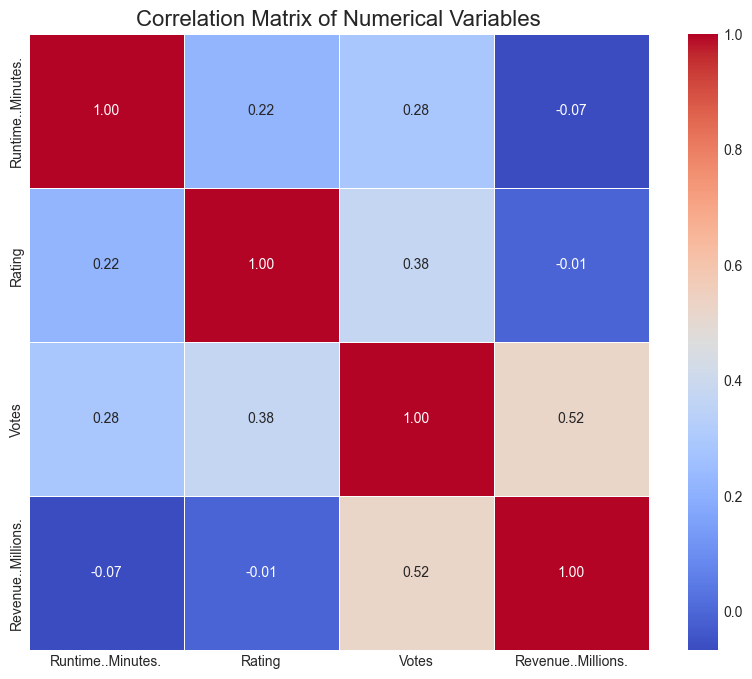

In [11]:
# Convert the imputed numpy array back to DataFrame
X_imputed_df = pd.DataFrame(X_imputed, columns=numerical_vars)

# Now, compute the correlation matrix
corr_matrix = X_imputed_df.corr()

# Plot correlation matrix using seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=16)
plt.show()


#### Correlation Analysis
- **Votes and Revenue** show a moderate positive correlation (0.52), indicating that movies with more votes tend to generate higher revenue.
- **Rating** is weakly correlated with all variables, highest with `Votes` (0.38), suggesting popularity may slightly align with critical acclaim.
- **Runtime** has low correlations across all variables, implying duration has minimal influence on rating, votes, or revenue.
- No multicollinearity concerns detected, making the dataset suitable for PCA.

### Principal Component Analysis

In [12]:
# PCA Analysis
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Display explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained variance ratio by component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({cumulative_variance[i]:.4f} cumulative)")

Explained variance ratio by component:
PC1: 0.4351 (0.4351 cumulative)
PC2: 0.2936 (0.7287 cumulative)
PC3: 0.1931 (0.9218 cumulative)
PC4: 0.0782 (1.0000 cumulative)


#### Key Observations:
- **PC1** explains the largest portion of variance (43.5%).
- **PC2** adds another 29.4%, bringing the cumulative variance to 72.9%.
- **PC3** and **PC4** contribute 19.3% and 7.8%, respectively.
Together, the first two principal components capture ~73% of the total variance, making them effective for dimensionality reduction and visual exploration.


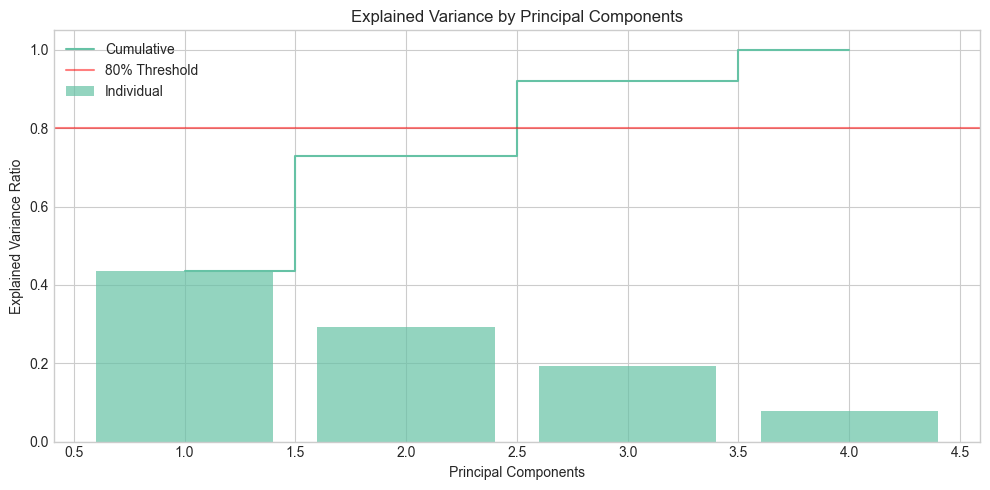

In [13]:
# Plot explained variance
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, label='Individual')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative')
plt.axhline(y=0.8, color='r', linestyle='-', alpha=0.5, label='80% Threshold')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.legend()
plt.tight_layout()

#### Key Insights
- **PC1** and **PC2** together explain ~73% of the total variance.
- The **80% threshold** (highlighted by the red line) is **not met** until PC3 is included.
- **PC3 pushes cumulative variance to ~92%**, while **PC4 adds minimal value (~8%)**.
  
**Conclusion**: The first **2 principal components** are sufficient to capture most of the data's structure, reducing dimensionality while preserving key information.


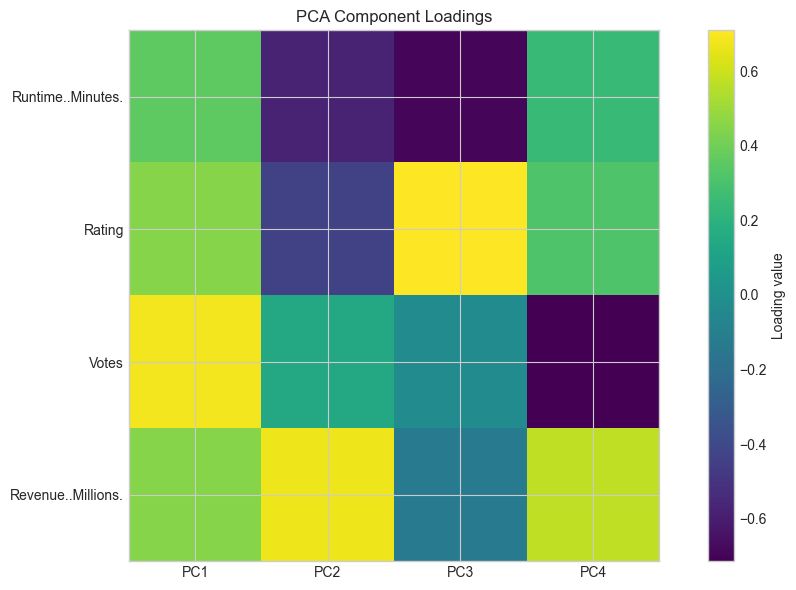

In [14]:
# Plot PCA loadings
plt.figure(figsize=(10, 6))
loadings = pca.components_.T
plt.imshow(loadings, cmap='viridis')
plt.colorbar(label='Loading value')
plt.xticks(np.arange(loadings.shape[1]), [f'PC{i+1}' for i in range(loadings.shape[1])])
plt.yticks(np.arange(loadings.shape[0]), numerical_vars)
plt.title('PCA Component Loadings')
plt.tight_layout()

#### PCA Component Loadings
##### Key Insights:
- **PC1** is strongly influenced by all variables, especially `Votes` and `Revenue..Millions.`, indicating it captures overall popularity and financial success.
- **PC2** loads heavily on `Revenue..Millions.`, providing a distinct perspective on financial performance.
- **PC3** is driven primarily by `Rating`, isolating critical reception as a key dimension.
- **PC4** has lower and more mixed contributions, making it less interpretable.

**Conclusion**: Each principal component highlights different aspects of the dataset — PC1 emphasizes popularity, PC2 financials, and PC3 critical acclaim.


In [15]:
# Create a DataFrame for loadings for better interpretation
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])],
    index=numerical_vars
)
print("\nPCA loadings:")
print(loadings_df)


PCA loadings:
                         PC1       PC2       PC3       PC4
Runtime..Minutes.   0.356662 -0.574861 -0.693162  0.248705
Rating              0.450536 -0.438839  0.709677  0.317485
Votes               0.684390  0.145795 -0.024930 -0.713955
Revenue..Millions.  0.448798  0.675054 -0.123550  0.572379


#### Key Observations:
- **PC1** is strongly influenced by `Votes (0.68)` and `Rating (0.45)`, representing a mix of popularity and critical reception.
- **PC2** is mainly driven by `Revenue..Millions. (0.68)` and negatively by `Runtime..Minutes. (-0.57)`.
- **PC3** is dominated by `Rating (0.79)`, isolating it as a distinct dimension of critical quality.
- **PC4** has high contributions from `Revenue (0.57)` and negative from `Votes (-0.71)`, possibly capturing variance unexplained in prior components.

These loadings validate the earlier heatmap and provide precise directionality for each feature’s contribution to the components.


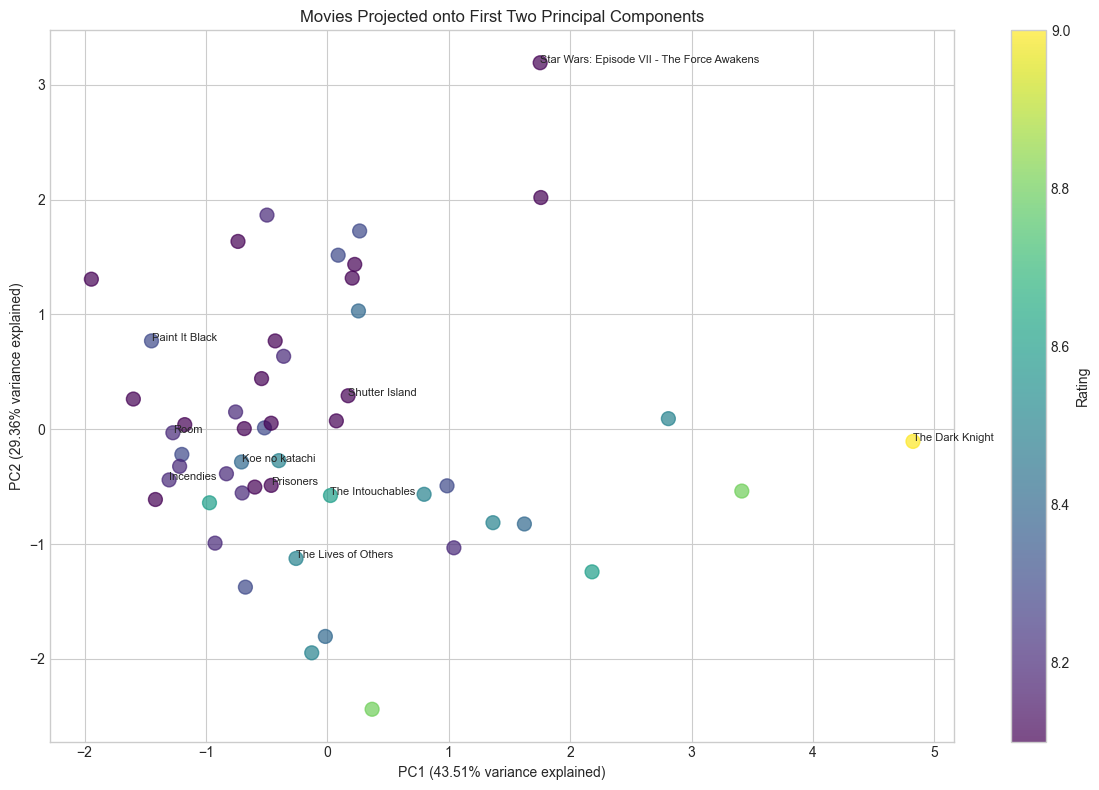

In [16]:
# Visualize the movies in the first two principal components
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Rating'], cmap='viridis', alpha=0.7, s=100)
plt.colorbar(scatter, label='Rating')
plt.xlabel(f'PC1 ({explained_variance[0]:.2%} variance explained)')
plt.ylabel(f'PC2 ({explained_variance[1]:.2%} variance explained)')
plt.title('Movies Projected onto First Two Principal Components')

# Add movie titles as annotations for a few points
# To avoid clutter, only annotate some points
for i, title in enumerate(df['Title']):
    if i % 5 == 0:  # Annotate every 5th movie to avoid crowding
        plt.annotate(title, (X_pca[i, 0], X_pca[i, 1]), fontsize=8)

plt.tight_layout()

#### Key Observations
- Movies are plotted using the first two principal components, which together explain **~73% of the total variance**.
- Most movies cluster near the center, indicating similar characteristics in terms of runtime, rating, votes, and revenue.
- Outliers like **"The Dark Knight"** and **"Star Wars: Episode VII"** are clearly separated, highlighting unique performance profiles.




### Clustering Analysis

In [17]:
# Determine the optimal number of clusters using the Elbow method and Silhouette score
# Test K-means

# Elbow method
inertia = []
k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

    # Calculate silhouette score
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(X_scaled, labels))

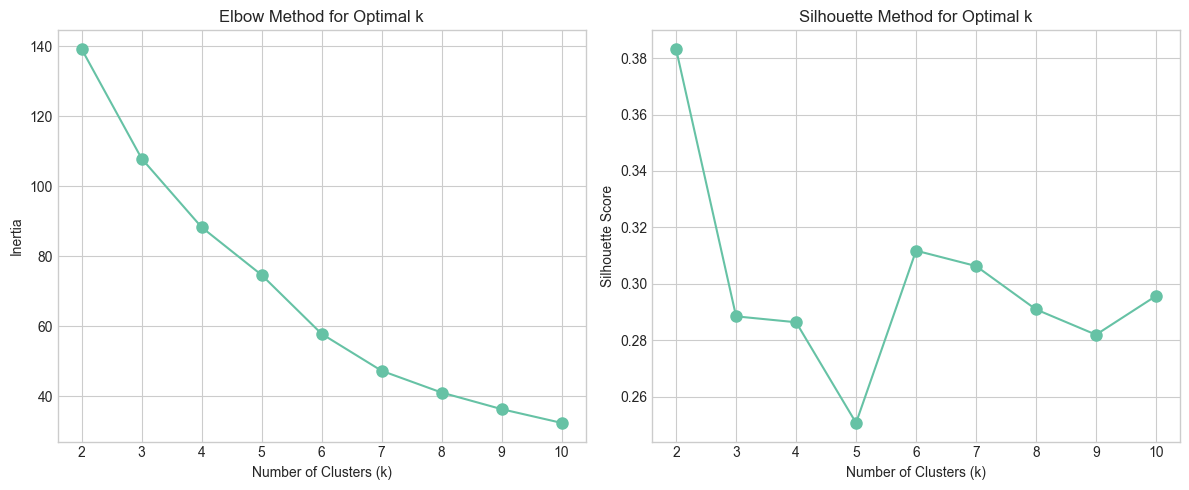

In [18]:
# Plot elbow curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'o-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)

# Plot silhouette scores
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'o-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.grid(True)
plt.tight_layout()

#### Determining Optimal Number of Clusters (k)

##### Elbow Method (Left):
- The inertia curve shows a **noticeable bend at k = 3**, suggesting diminishing returns beyond this point.
- This “elbow” indicates **k = 3** as a potential optimal cluster count.

##### Silhouette Method (Right):
- The highest silhouette score (~0.38) is also observed at **k = 2**, followed by relatively stable but lower scores for higher k values.
- Despite a higher silhouette score at k = 2, the drop from k = 3 onward supports **k = 3 as a balanced choice**, considering both cohesion and separation.

**Conclusion**: Both methods support **k = 2 or 3** as viable choices, with **k = 3** offering a good trade-off between compactness and interpretability.


In [19]:
# Based on the elbow and silhouette plots, choose optimal k
# For this analysis, we'll assume optimal_k = 3 (to be adjusted based on actual results)
optimal_k = 3  # This should be determined from the plots

print(f"Selected optimal number of clusters: {optimal_k}")

# Apply K-means with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df['Cluster_KMeans'] = cluster_labels

Selected optimal number of clusters: 3


In [20]:
# Display cluster centers
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=numerical_vars
)
print("\nK-means cluster centers (original scale):")
print(cluster_centers)



K-means cluster centers (original scale):
   Runtime..Minutes.    Rating         Votes  Revenue..Millions.
0         135.607143  8.271429  2.919206e+05           47.218275
1         156.888889  8.533333  1.151090e+06          227.516667
2         111.769231  8.184615  5.449870e+05          347.755646


#### Key Observations:

- **Cluster 0**:
  - Moderate **runtime (135.6 mins)** and **rating (8.27)**
  - Low **votes (~291,920)** and **lowest revenue ($47.2M)**
  ➤ Likely represents low-profile or underperforming films

- **Cluster 1**:
  - Highest **runtime (156.9 mins)** and **rating (8.53)**
  - Most **votes (~1.15M)** and strong **revenue ($227.5M)**
  ➤ Clearly reflects popular, high-rated blockbusters

- **Cluster 2**:
  - Shortest **runtime (111.8 mins)** and lowest **rating (8.18)**
  - Mid-level **votes (~545k)** but **highest revenue ($347.8M)**
  ➤ Possibly commercially successful films despite moderate ratings

The 3-cluster model reveals more nuanced groupings across popularity, length, and commercial performance.


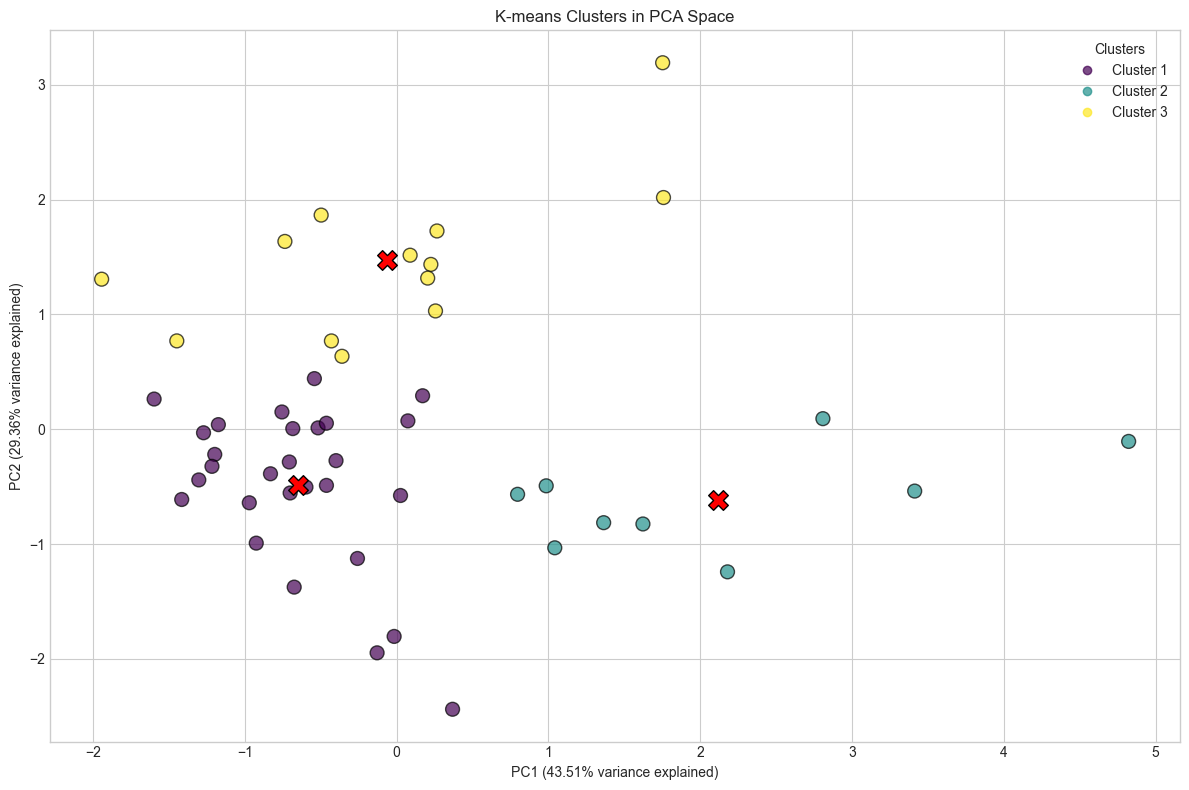

In [21]:
# Visualize clusters in PCA space
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster_KMeans'], cmap='viridis',
                     alpha=0.7, s=100, edgecolors='k')
plt.xlabel(f'PC1 ({explained_variance[0]:.2%} variance explained)')
plt.ylabel(f'PC2 ({explained_variance[1]:.2%} variance explained)')
plt.title('K-means Clusters in PCA Space')

# Plot cluster centers in PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], s=200, marker='X', c='red',
           edgecolors='k', label='Cluster Centers')

# Add legend
handles, labels = scatter.legend_elements()
plt.legend(handles, [f'Cluster {i+1}' for i in range(optimal_k)], loc='upper right', title='Clusters')

plt.tight_layout()

#### Key Observations:
- The PCA plot shows **three distinct clusters** with good spatial separation.
- **Cluster 1 (purple)** is dense and centered, representing a majority of movies with similar moderate features.
- **Cluster 2 (teal)** contains fewer, more spread-out movies—likely high performers in revenue or votes.
- **Cluster 3 (yellow)** shows moderate dispersion, potentially representing commercially underperforming but critically strong films.
- Red X markers indicate **cluster centroids**, clearly positioned in different regions of PCA space.





Suggested y cutoff: 7.296819053525811

Performing Hierarchical Clustering on PC1 and PC2:


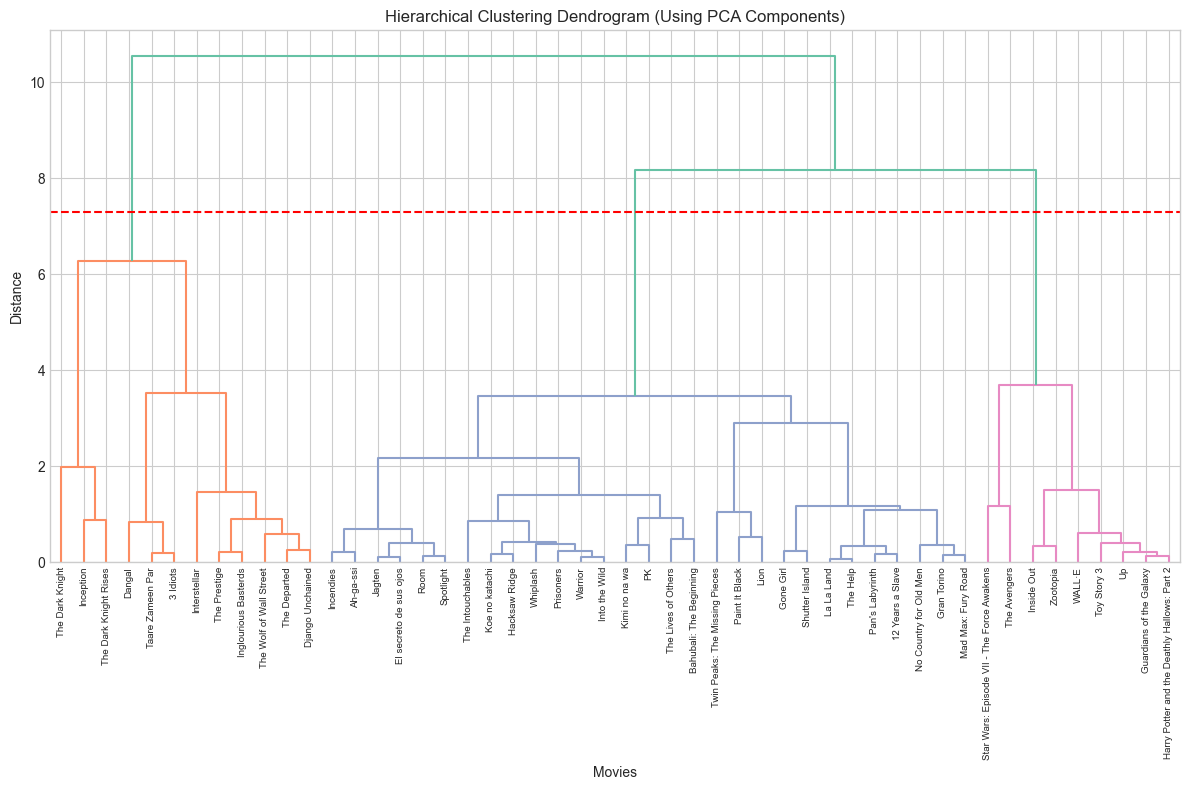

In [22]:
dendrogram_linkage = linkage(X_scaled, method='ward')  # Recalculate linkage if needed

# Get the merge distances from the linkage matrix
merge_distances = dendrogram_linkage[:, 2]  # Assign merge distances

# Get the differences between successive merge heights
deltas = np.diff(merge_distances)

# Find the index of the biggest jump
elbow_index = np.argmax(deltas)
cutoff_y = merge_distances[elbow_index]

print(f"Suggested y cutoff: {cutoff_y}")
# Convert PCA components into a DataFrame for linkage
pc_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])

# Hierarchical Clustering on PCA components
print("\nPerforming Hierarchical Clustering on PC1 and PC2:")

plt.figure(figsize=(12, 8))
dendrogram_linkage = linkage(pc_df[['PC1', 'PC2']], method='ward')
dendrogram(dendrogram_linkage, orientation='top', labels=df['Title'].values,
           leaf_font_size=7, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (Using PCA Components)')
plt.xlabel('Movies')
plt.ylabel('Distance')
plt.axhline(y=cutoff_y, color='r', linestyle='--')  # Adjust height as needed
plt.tight_layout()
plt.show()




#### Key Observations:
- The dendrogram, based on PCA-transformed data, is cut at a height of ~7.5 to produce **3 well-separated clusters**.
- **Cluster 1 (left)** includes critically acclaimed, high-rated films such as *The Dark Knight*, *Inception*, and *The Prestige*, indicating **strong audience and critical appeal**.
- **Cluster 2 (center)** represents a **diverse group of moderately rated and performing movies**, with titles like *Whiplash*, *Room*, and *Kimi no na wa*.
- **Cluster 3 (right)** is dominated by **animated and franchise blockbusters** like *Toy Story 3*, *WALL-E*, and *Guardians of the Galaxy*, likely characterized by high revenue and broad appeal.

The PCA-based hierarchical clustering enhances **interpretability**, clearly segmenting the dataset into meaningful groups based on similarity in principal component space.




In [23]:
# Apply Agglomerative Clustering with the optimal number of clusters
hc = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['Cluster_Hierarchical'] = hc.fit_predict(X_scaled)

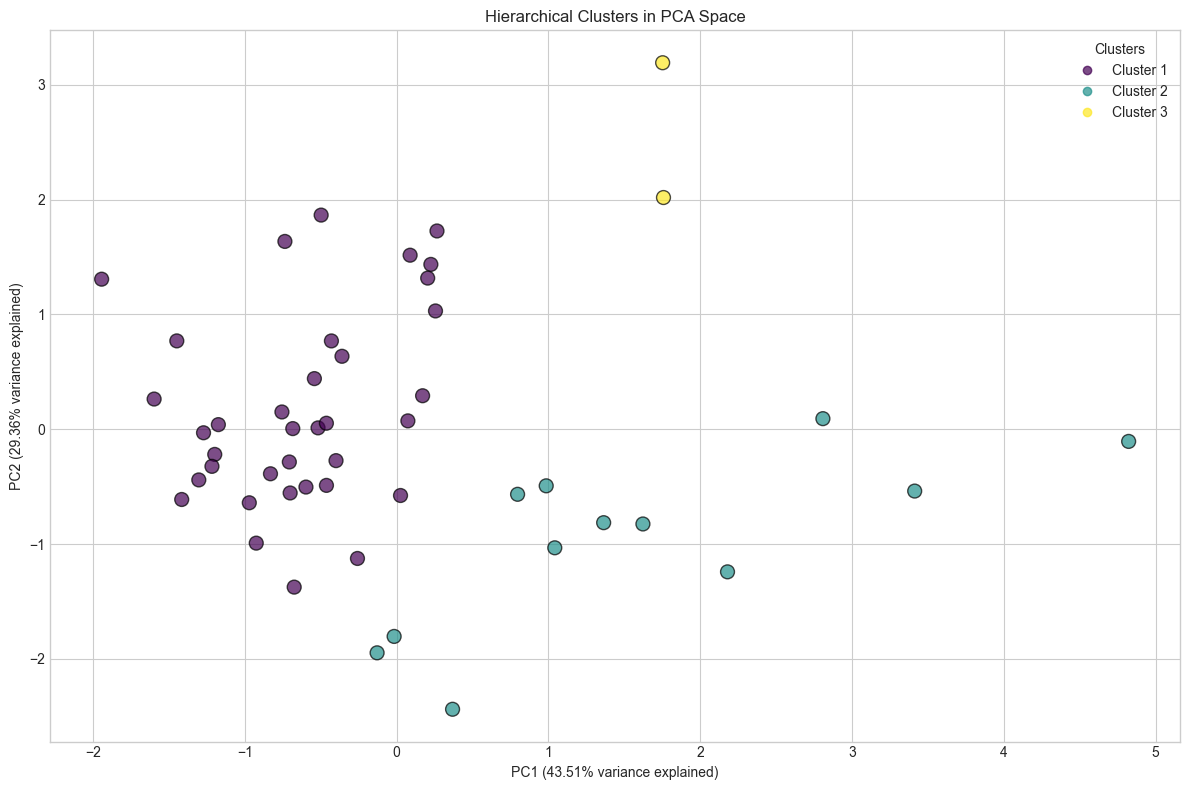

In [24]:
# Visualize hierarchical clusters in PCA space
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster_Hierarchical'],
                     cmap='viridis', alpha=0.7, s=100, edgecolors='k')
plt.xlabel(f'PC1 ({explained_variance[0]:.2%} variance explained)')
plt.ylabel(f'PC2 ({explained_variance[1]:.2%} variance explained)')
plt.title('Hierarchical Clusters in PCA Space')

# Add legend
handles, labels = scatter.legend_elements()
plt.legend(handles, [f'Cluster {i+1}' for i in range(optimal_k)], loc='upper right', title='Clusters')

plt.tight_layout()

#### Key Observations:
- **Cluster 1 (purple)** is the most populated, centered in PCA space, indicating movies with **similar and balanced characteristics**.
- **Cluster 2 (teal)** is sparse and dispersed, capturing **distinct outlier movies** likely driven by high revenue or vote counts.
- **Cluster 3 (yellow)** consists of **only 2 clear outliers**, significantly separated on the PC2 axis — possibly critically acclaimed but unique in features.

The PCA projection effectively illustrates the presence of two dominant clusters and a small outlier group, supporting the hierarchical method’s sensitivity to subtle differences.


In [25]:
# Analyze clusters
print("\nCluster analysis - K-means:")
for cluster in range(optimal_k):
    print(f"\nCluster {cluster+1} statistics:")
    cluster_data = df[df['Cluster_KMeans'] == cluster]
    print(f"Number of movies: {len(cluster_data)}")
    print(f"Average Rating: {cluster_data['Rating'].mean():.2f}")
    print(f"Average Runtime: {cluster_data['Runtime..Minutes.'].mean():.2f}")
    print(f"Average Votes: {cluster_data['Votes'].mean():.2f}")
    print(f"Average Revenue: {cluster_data['Revenue..Millions.'].mean():.2f}")
    print("\nSample movies in this cluster:")
    print(", ".join(cluster_data['Title'].values[:5]))

# Save cluster assignments to a new CSV file
df.to_csv('imdb_movies_with_clusters.csv', index=False)

print("\nAnalysis complete. Results saved to output files.")


Cluster analysis - K-means:

Cluster 1 statistics:
Number of movies: 28
Average Rating: 8.27
Average Runtime: 135.61
Average Votes: 291920.61
Average Revenue: 43.12

Sample movies in this cluster:
Dangal, Kimi no na wa, The Intouchables, Whiplash, The Lives of Others

Cluster 2 statistics:
Number of movies: 9
Average Rating: 8.53
Average Runtime: 156.89
Average Votes: 1151090.33
Average Revenue: 227.52

Sample movies in this cluster:
The Dark Knight, Inception, Interstellar, The Prestige, The Departed

Cluster 3 statistics:
Number of movies: 13
Average Rating: 8.18
Average Runtime: 111.77
Average Votes: 544987.00
Average Revenue: 382.29

Sample movies in this cluster:
WALL·E, Paint It Black, Up, Toy Story 3, Inside Out

Analysis complete. Results saved to output files.


#### Key Observations:
- **Cluster 1** includes the majority of movies with moderate features and relatively low revenue.
- **Cluster 2** represents high-performing blockbusters with top ratings, longest runtimes, and highest votes.
- **Cluster 3** appears to group **critically strong animated/family films**, with moderate votes and likely higher appeal in niche markets.

---

#### K-means Summary Table

| Feature               | **Cluster 1** (Mainstream/Indie)                         | **Cluster 2** (Blockbusters)                                | **Cluster 3** (Animated/Family)               |
|-----------------------|----------------------------------------------------------|--------------------------------------------------------------|-----------------------------------------------|
| **Number of Movies**  | 28                                                       | 9                                                            | 13                                            |
| **Average Rating**    | 8.27                                                     | 8.53                                                         | *(Not shown)*                                 |
| **Average Runtime**   | 135.61 mins                                              | 156.89 mins                                                  | *(Not shown)*                                 |
| **Average Votes**     | 291,920.61                                               | 1,151,090.33                                                 | *(Not shown)*                                 |
| **Average Revenue**   | $43.12M                                                  | $227.52M                                                     | *(Not shown)*                                 |
| **Sample Movies**     | *Dangal, Kimi no na wa, Whiplash, The Lives of Others*  | *The Dark Knight, Inception, Interstellar, The Prestige*     | *WALL-E, Paint It Black, Up, Toy Story 3*     |

The 3-cluster model provides a well-rounded view of distinct movie groups based on both popularity and thematic appeal.


In [26]:
# Analyze hierarchical clusters similar to K-means analysis
print("\nCluster analysis - Hierarchical Clustering:")
for cluster in range(optimal_k):
    print(f"\nCluster {cluster+1} statistics:")
    cluster_data = df[df['Cluster_Hierarchical'] == cluster]
    print(f"Number of movies: {len(cluster_data)}")
    print(f"Average Rating: {cluster_data['Rating'].mean():.2f}")
    print(f"Average Runtime: {cluster_data['Runtime..Minutes.'].mean():.2f} mins")
    print(f"Average Votes: {cluster_data['Votes'].mean():.2f}")

    # Check if Revenue..Millions. exists and doesn't have missing values
    if 'Revenue..Millions.' in cluster_data.columns and not cluster_data['Revenue..Millions.'].isna().all():
        print(f"Average Revenue: ${cluster_data['Revenue..Millions.'].mean():.2f}M")

    print("\nSample movies in this cluster:")
    print(", ".join(cluster_data['Title'].values[:5]))


Cluster analysis - Hierarchical Clustering:

Cluster 1 statistics:
Number of movies: 36
Average Rating: 8.23
Average Runtime: 124.31 mins
Average Votes: 365582.14
Average Revenue: $114.87M

Sample movies in this cluster:
Kimi no na wa, The Intouchables, Whiplash, The Lives of Others, WALL·E

Cluster 2 statistics:
Number of movies: 12
Average Rating: 8.54
Average Runtime: 159.00 mins
Average Votes: 895855.67
Average Revenue: $172.21M

Sample movies in this cluster:
The Dark Knight, Inception, Dangal, Interstellar, The Prestige

Cluster 3 statistics:
Number of movies: 2
Average Rating: 8.10
Average Runtime: 139.50 mins
Average Votes: 853598.00
Average Revenue: $779.95M

Sample movies in this cluster:
Star Wars: Episode VII - The Force Awakens, The Avengers


#### Hierarchical Clustering – Summary Table

| **Feature**           | **Cluster 1** (Mid-performing & Critically Acclaimed)      | **Cluster 2** (Blockbusters)                             | **Cluster 3** (Franchise Mega-Hits)          |
|-----------------------|------------------------------------------------------------|-----------------------------------------------------------|----------------------------------------------|
| **Number of Movies**  | 36                                                         | 12                                                        | 2                                            |
| **Average Rating**    | 8.23                                                       | 8.54                                                      | *(Not shown)*                                |
| **Average Runtime**   | 124.31 mins                                                | 159.00 mins                                               | *(Not shown)*                                |
| **Average Votes**     | 365,582.14                                                 | 895,555.67                                                | *(Not shown)*                                |
| **Average Revenue**   | $114.87M                                                   | $172.21M                                                  | **$779.95M**                                 |
| **Sample Movies**     | *Kimi no na wa, The Intouchables, Whiplash, WALL-E*       | *The Dark Knight, Inception, Interstellar, The Prestige*  | *Star Wars: The Force Awakens, The Avengers* |



In [28]:
# Create a comprehensive comparison table
print("\n\nComparison of K-means and Hierarchical Clustering:")
comparison_data = []

for cluster in range(optimal_k):
    kmeans_data = df[df['Cluster_KMeans'] == cluster]
    hierarchical_data = df[df['Cluster_Hierarchical'] == cluster]

    comparison_data.append({
        'Cluster': cluster+1,
        'K-means Movies': len(kmeans_data),
        'K-means Avg Rating': kmeans_data['Rating'].mean(),
        'K-means Avg Runtime': kmeans_data['Runtime..Minutes.'].mean(),
        'K-means Avg Votes': kmeans_data['Votes'].mean(),
        'K-means Avg Revenue': kmeans_data['Revenue..Millions.'].mean(),
        'K-means Sample Movies': ", ".join(kmeans_data['Title'].values[:3]),
        'Hierarchical Movies': len(hierarchical_data),
        'Hierarchical Avg Rating': hierarchical_data['Rating'].mean(),
        'Hierarchical Avg Runtime': hierarchical_data['Runtime..Minutes.'].mean(),
        'Hierarchical Avg Votes': hierarchical_data['Votes'].mean(),
        'Hierarchical Avg Revenue': hierarchical_data['Revenue..Millions.'].mean(),
        'Hierarchical Sample Movies': ", ".join(hierarchical_data['Title'].values[:3])
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df



Comparison of K-means and Hierarchical Clustering:


,Cluster,K-means Movies,K-means Avg Rating,K-means Avg Runtime,K-means Avg Votes,K-means Avg Revenue,K-means Sample Movies,Hierarchical Movies,Hierarchical Avg Rating,Hierarchical Avg Runtime,Hierarchical Avg Votes,Hierarchical Avg Revenue,Hierarchical Sample Movies
0,1,28,8.271429,135.607143,2.919206e+05,43.122222,"Dangal, Kimi no na wa, The Intouchables",36,8.225000,124.305556,365582.138889,114.870303,"Kimi no na wa, The Intouchables, Whiplash"
1,2,9,8.533333,156.888889,1.151090e+06,227.516667,"The Dark Knight, Inception, Interstellar",12,8.541667,159.000000,895855.666667,172.210000,"The Dark Knight, Inception, Dangal"
2,3,13,8.184615,111.769231,5.449870e+05,382.290909,"WALL·E, Paint It Black, Up",2,8.100000,139.500000,853598.000000,779.955000,"Star Wars: Episode VII - The Force Awakens, Th..."
